In [1]:
import json
import numpy as np
import os
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from factor_analyzer import Rotator

import ot 
from sklearn.manifold import MDS
from scipy.spatial.distance import pdist, squareform

from scipy.cluster.hierarchy import linkage, dendrogram

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.manifold import MDS
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.metrics import classification_report, accuracy_score
from scipy.spatial.distance import pdist, squareform
from factor_analyzer import Rotator
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold

pd.set_option('display.max_columns', None)

In [2]:
appraisal_columns = ["pleasantness", "enjoyment", "consider", "attention", "understand", "control-situational", "control-self", "control-other", "certainty", "problem", "obstacle", "legitimacy-cheated", "legitimacy-fair", "responsibility-self", "responsibility-other", "exert", "effort"]
def process_single_output(output_text): 
    if not isinstance(output_text, str): 
        output_text = output_text["content"]

    if "[/INST]" in output_text: 
        output_text = output_text.split("[/INST]")[1] # case-by-case handling for mistral
    
    if "{" in output_text: 
        response = output_text.split("{")[1] # considering whatever comes after the first JSON
        response = response.split("}")[0]
        response = "{" + response + "}"
        response_json = ""
        try: 
            response_json = json.loads(response)
        except Exception as e: 
            # print(f"Could not load JSON accurately for model output = {response}")
            return None
        
        if not response_json:
            return None
        
        if "Question 1" not in response_json or "Question 2" not in response_json: 
            # print(f"Invalid keys found in response JSON = {response_json}")
            return None
        
        q1 = response_json["Question 1"]
        q2 = response_json["Question 2"]
        return q1, q2

    return None

In [3]:
def create_appraisal_emotion_df(file): 
    appraisal_dict = {
        "pleasantness": [],
        "enjoyment": [],
        "consider": [],
        "attention": [],
        "understand": [],
        "control-situational": [],
        "control-self": [],
        "control-other": [],
        "certainty": [],
        "problem": [],
        "obstacle": [],
        "legitimacy-cheated": [],
        "legitimacy-fair": [],
        "responsibility-self": [],
        "responsibility-other": [],
        "exert": [],
        "effort": [],
        "emotion_label": []
    }

    with open(file, "r") as f: 
        count = 0
        for line in f.readlines(): 
            curr_json = json.loads(line)
            processed_output = process_single_output(curr_json["output"])
            
            rating = None
            if processed_output: 
                a1, a2 = processed_output
                if isinstance(a2, list):
                    if len(a2) == 2: 
                        rating = a2[1]
            curr_dim = curr_json["id"].split("_")[-1]
            appraisal_dict[curr_dim].append(rating)
            if count % 17 == 0:
                appraisal_dict["emotion_label"].append(curr_json["id"].split("_")[1])
            count += 1
        for key, value in appraisal_dict.items(): 
            print(f"{key}: {len(appraisal_dict[key])}")

    df = pd.DataFrame(appraisal_dict)
    df = df.fillna(0)
    df = df.applymap(lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x)
    df = df.applymap(lambda x: int(x) if isinstance(x, str) and x.isdigit() else x)
    return df

In [4]:
# calculate Wasserstein Distance
def L2square(supp1, supp2):
    """
    Compute pairwise squared Euclidean distances.
    supp1: (dim, n1), supp2: (dim, n2)
    Returns: (n1, n2) distance matrix
    """
    supp1 = supp1.T  # shape (n1, dim)
    supp2 = supp2.T  # shape (n2, dim)
    
    d1_sq = np.sum(supp1**2, axis=1, keepdims=True)  # (n1, 1)
    d2_sq = np.sum(supp2**2, axis=1, keepdims=True).T  # (1, n2)
    pairwise_sq_dist = d1_sq + d2_sq - 2 * np.dot(supp1, supp2.T)
    return pairwise_sq_dist

def ot_distance(cost, p1, p2):
    """
    Solve the OT problem with cost matrix.
    cost: (n1, n2), p1: (n1,), p2: (n2,)
    Returns: total cost and transport plan (gammaij)
    """
    p1 = p1 / np.sum(p1)
    p2 = p2 / np.sum(p2)
    
    gammaij = ot.emd(p1, p2, cost)
    objval = np.sum(gammaij * cost)
    return objval, gammaij

def DiscreteWasserstein(supp1, supp2, w1, w2):
    """
    Compute squared Wasserstein distance between two discrete distributions.

    Parameters:
    - supp1: ndarray (dim, n1)
    - supp2: ndarray (dim, n2)
    - w1: ndarray (n1,) probabilities for supp1
    - w2: ndarray (n2,) probabilities for supp2

    Returns:
    - dist: float, squared Wasserstein distance
    - gammaij: ndarray (n1, n2), optimal transport plan
    """
    pairdist = L2square(supp1, supp2)
    dist, gammaij = ot_distance(pairdist, w1, w2)
    return dist, gammaij


In [5]:
# Example subject dataframe (should be replaced with actual data)
# Assuming 16 appraisal dimensions and 1 emotion label
# Let's simulate a sample structure
def get_within_subject_representation(df, name):
    np.random.seed(42)
    emotions = ["happiness", "surprise", "pride", "interest", "hope", "boredom", "disgust", "contempt", "guilt", "fear", "shame", "sadness", "anger", "challenge", "frustration"]
    n_emotions = len(emotions)
    appraisal_features = appraisal_columns

    # Step 1: Calculate Wasserstein distances between each pair of emotions
    emotion_groups = {emotion: df[df['emotion_label'] == emotion].drop(columns='emotion_label').values for emotion in emotions}

    emotion_distances = pd.DataFrame(index=emotions, columns=emotions, dtype=float)
    for e1 in emotions:
        for e2 in emotions:
            # Compute average pairwise Wasserstein distance
            e1_dist = emotion_groups[e1]
            e2_dist = emotion_groups[e2]
            
            supp1 = e1_dist.T
            supp2 = e2_dist.T

            w1 = np.ones(supp1.shape[1]) / supp1.shape[1]
            w2 = np.ones(supp2.shape[1]) / supp2.shape[1]

            if e1 == e2:
                dist_sq, _ = DiscreteWasserstein(supp1, supp2, w1, w1)
            else: 
                dist_sq, _ = DiscreteWasserstein(supp1, supp2, w1, w2)
            
            emotion_distances.loc[e1, e2] = np.sqrt(dist_sq)

    # print(emotion_distances)
    # Step 2: MDS visualization
    # mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
    # mds_coords = mds.fit_transform(emotion_distances)

    # # Create a DataFrame for plotting
    # mds_df = pd.DataFrame(mds_coords, columns=['Dimension 1', 'Dimension 2'])
    # mds_df['emotion'] = emotions
    # return mds_df

    # Plot
    # plt.figure(figsize=(10, 8))
    # sns.scatterplot(data=mds_df, x='Dimension 1', y='Dimension 2', hue='emotion', s=100)
    # for i, row in mds_df.iterrows():
    #     plt.text(row['Dimension 1'] + 0.01, row['Dimension 2'], row['emotion'], fontsize=18)
    # plt.title(f'{name}', fontsize=24)
    # plt.xlabel('Dimension 1', fontsize=20)
    # plt.ylabel('Dimension 2', fontsize=20)
    # plt.grid(True)
    # plt.legend(fontsize=14)
    # plt.tight_layout()
    # filepath = name.lower().replace(" ", "_") + "_mds_visualization.pdf"
    # plt.savefig(filepath, format="pdf", bbox_inches="tight")
    # plt.show()
    return emotion_distances

def rank_emotion_distances(df: pd.DataFrame):
    ranked_dict = {}
    print(df.head())

    for emotion in df.index:
        # Copy row and drop self-distance
        distances = df.loc[emotion].copy()
        distances = distances.drop(emotion)
        
        # Sort and keep as (emotion, distance) pairs
        sorted_emotions = distances.sort_values()
        ranked_dict[emotion] = list(zip(sorted_emotions.index, sorted_emotions.values))

    return ranked_dict


In [6]:
def find_values(df): 
    min_val = 10000
    max_val = 0
    avg = 0
    count = 0 
    columns = df.columns
    all_nz_dist = [] 

    for row in columns: 
        for col in columns: 
            if row == col: 
                continue 
            dist = df.loc[row, col]
            min_val = min(min_val, dist)
            max_val = max(max_val, dist)
            count += 1 
            avg += dist
            all_nz_dist.append(dist)

    print(f"Minimum distance = {min_val}")
    print(f"Maximum distance = {max_val}")
    print(f"Average distace = {float(avg)/count}")

    return all_nz_dist

pleasantness: 274
enjoyment: 274
consider: 274
attention: 274
understand: 274
control-situational: 274
control-self: 274
control-other: 274
certainty: 274
problem: 274
obstacle: 274
legitimacy-cheated: 274
legitimacy-fair: 274
responsibility-self: 274
responsibility-other: 274
exert: 274
effort: 274
emotion_label: 274


/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_44273/2130613728.py:45: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x)
/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_44273/2130613728.py:46: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: int(x) if isinstance(x, str) and x.isdigit() else x)


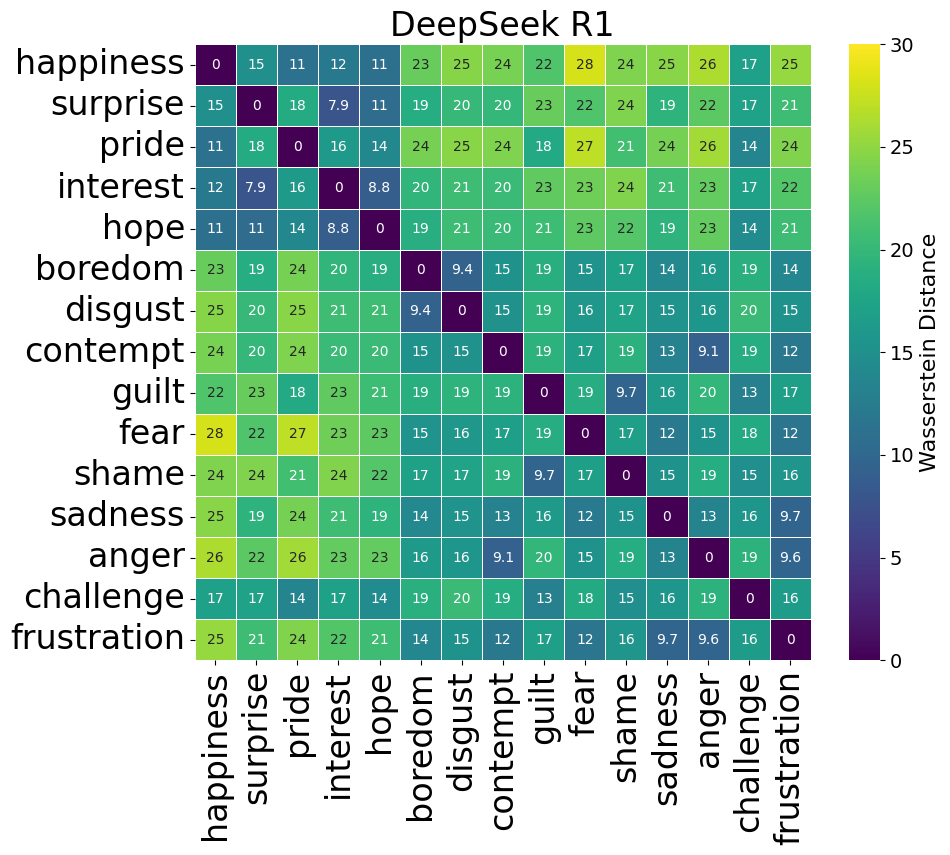

Minimum distance = 7.864477096412703
Maximum distance = 28.106811579096927
Average distace = 18.200399914386914


In [8]:
deepseek_r1_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/deepseek_r1_with_emotion_vanilla.jsonl")
emotion_distance = get_within_subject_representation(deepseek_r1_df, "DeepSeek R1")
# print(emotion_distance)

plt.figure(figsize=(10, 8))
sns.heatmap(emotion_distance, vmin=0, vmax=30, annot=True, cmap="viridis", square=True, linewidths=0.5, cbar_kws={"label": "Wasserstein Distance"})
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
cbar = plt.gca().collections[0].colorbar
cbar.ax.tick_params(labelsize=14)                 # Tick labels on colorbar
cbar.set_label("Wasserstein Distance", fontsize=16)  # Label font size
plt.title("DeepSeek R1", fontsize=24)
plt.savefig("deepseek_r1_wasserstein_distance.pdf", format="pdf", bbox_inches="tight")
plt.show()

ds_distribution = find_values(emotion_distance)

pleasantness: 274
enjoyment: 274
consider: 274
attention: 274
understand: 274
control-situational: 274
control-self: 274
control-other: 274
certainty: 274
problem: 274
obstacle: 274
legitimacy-cheated: 274
legitimacy-fair: 274
responsibility-self: 274
responsibility-other: 274
exert: 274
effort: 274
emotion_label: 274


/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_44273/2130613728.py:45: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x)
/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_44273/2130613728.py:46: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: int(x) if isinstance(x, str) and x.isdigit() else x)


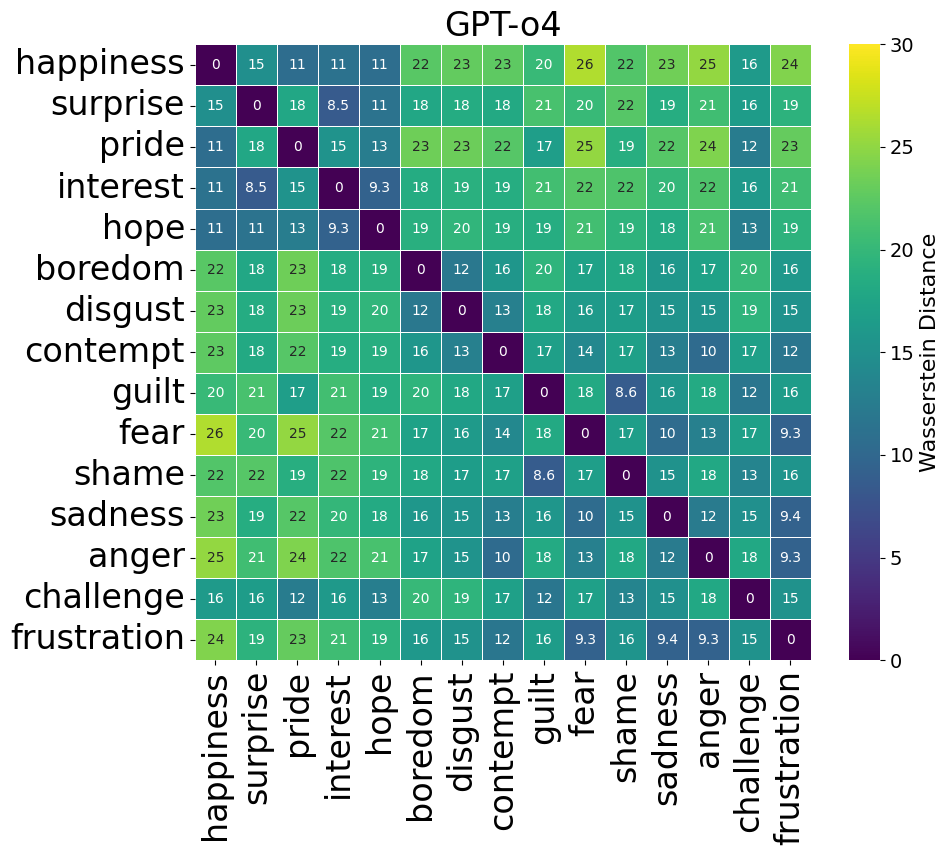

Minimum distance = 8.542110222821027
Maximum distance = 26.400487008495013
Average distace = 17.29439822226947


In [9]:
gpt_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/gpt_with_emotion_vanilla.jsonl")
emotion_distance = get_within_subject_representation(gpt_df, "GPT")

plt.figure(figsize=(10, 8))
sns.heatmap(emotion_distance, vmin=0, vmax=30, annot=True, cmap="viridis", square=True, linewidths=0.5, cbar_kws={"label": "Wasserstein Distance"})
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
cbar = plt.gca().collections[0].colorbar
cbar.ax.tick_params(labelsize=14)                 # Tick labels on colorbar
cbar.set_label("Wasserstein Distance", fontsize=16)  # Label font size
plt.title("GPT-o4", fontsize=24)
plt.savefig("gpt_wasserstein_distance.pdf", format="pdf", bbox_inches="tight")
plt.show()

gpt_distribution = find_values(emotion_distance)

pleasantness: 274
enjoyment: 274
consider: 274
attention: 274
understand: 274
control-situational: 274
control-self: 274
control-other: 274
certainty: 274
problem: 274
obstacle: 274
legitimacy-cheated: 274
legitimacy-fair: 274
responsibility-self: 274
responsibility-other: 274
exert: 274
effort: 274
emotion_label: 274


/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_44273/2130613728.py:45: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x)
/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_44273/2130613728.py:46: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: int(x) if isinstance(x, str) and x.isdigit() else x)


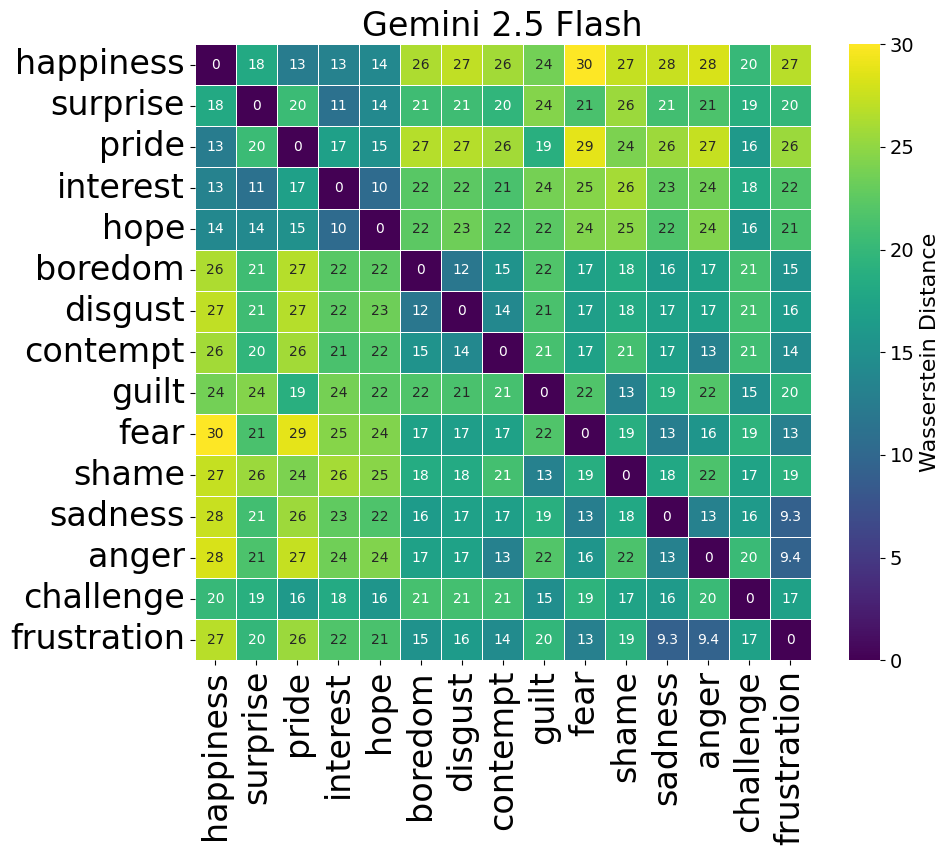

Minimum distance = 9.253377761660873
Maximum distance = 30.387497429041435
Average distace = 19.893416400077914


In [10]:
gemini_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/gemini_2_5_flash_with_emotion_vanilla.jsonl")
emotion_distance = get_within_subject_representation(gemini_df, "Gemini")

plt.figure(figsize=(10, 8))
sns.heatmap(emotion_distance, vmin=0, vmax=30, annot=True, cmap="viridis", square=True, linewidths=0.5, cbar_kws={"label": "Wasserstein Distance"})
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
cbar = plt.gca().collections[0].colorbar
cbar.ax.tick_params(labelsize=14)                 # Tick labels on colorbar
cbar.set_label("Wasserstein Distance", fontsize=16)  # Label font size
plt.title("Gemini 2.5 Flash", fontsize=24)
plt.savefig("gemini_wasserstein_distance.pdf", format="pdf", bbox_inches="tight")
plt.show()

gemini_distribution = find_values(emotion_distance)

pleasantness: 274
enjoyment: 274
consider: 274
attention: 274
understand: 274
control-situational: 274
control-self: 274
control-other: 274
certainty: 274
problem: 274
obstacle: 274
legitimacy-cheated: 274
legitimacy-fair: 274
responsibility-self: 274
responsibility-other: 274
exert: 274
effort: 274
emotion_label: 274


/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_44273/2130613728.py:45: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x)
/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_44273/2130613728.py:46: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: int(x) if isinstance(x, str) and x.isdigit() else x)


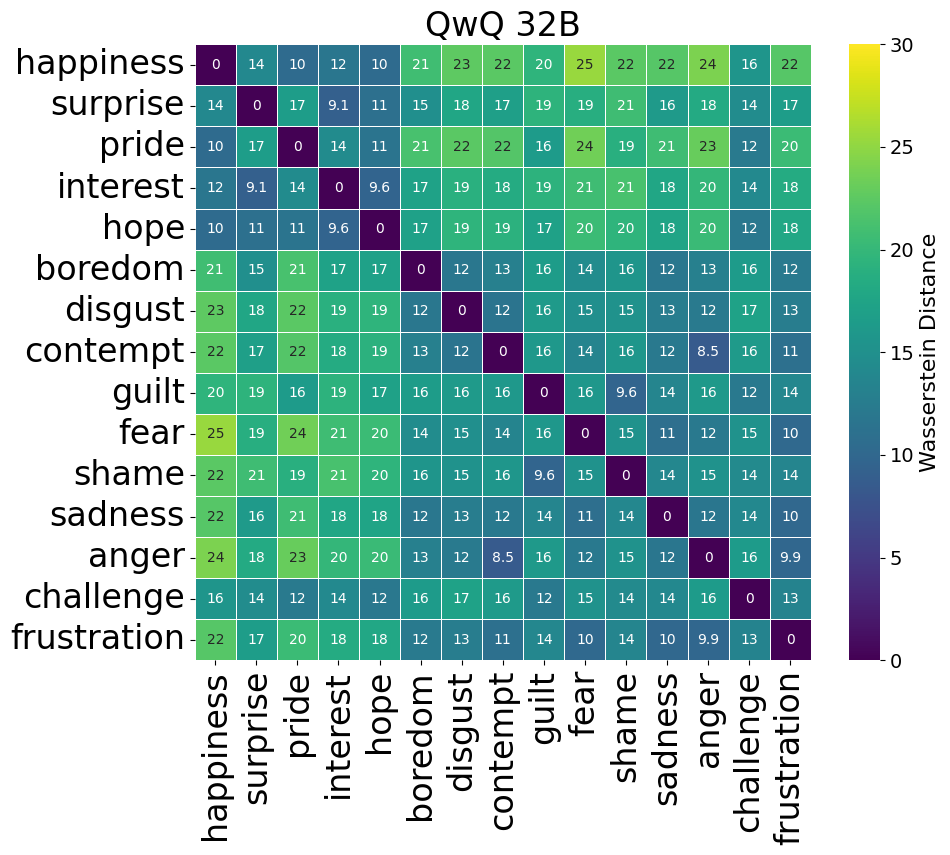

Minimum distance = 8.524265458341736
Maximum distance = 25.366175453600743
Average distace = 16.03930579266873


In [11]:
qwq_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/qwq_with_emotion_vanilla.jsonl")
emotion_distance = get_within_subject_representation(qwq_df, "QwQ 32B")

plt.figure(figsize=(10, 8))
sns.heatmap(emotion_distance, vmin=0, vmax=30, annot=True, cmap="viridis", square=True, linewidths=0.5, cbar_kws={"label": "Wasserstein Distance"})
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
cbar = plt.gca().collections[0].colorbar
cbar.ax.tick_params(labelsize=14)                 # Tick labels on colorbar
cbar.set_label("Wasserstein Distance", fontsize=16)  # Label font size
plt.title("QwQ 32B", fontsize=24)
plt.savefig("qwq_wasserstein_distance.pdf", format="pdf", bbox_inches="tight")
plt.show()

qwq_distribution = find_values(emotion_distance)

pleasantness: 274
enjoyment: 274
consider: 274
attention: 274
understand: 274
control-situational: 274
control-self: 274
control-other: 274
certainty: 274
problem: 274
obstacle: 274
legitimacy-cheated: 274
legitimacy-fair: 274
responsibility-self: 274
responsibility-other: 274
exert: 274
effort: 274
emotion_label: 274


/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_44273/2130613728.py:45: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x)
/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_44273/2130613728.py:46: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: int(x) if isinstance(x, str) and x.isdigit() else x)


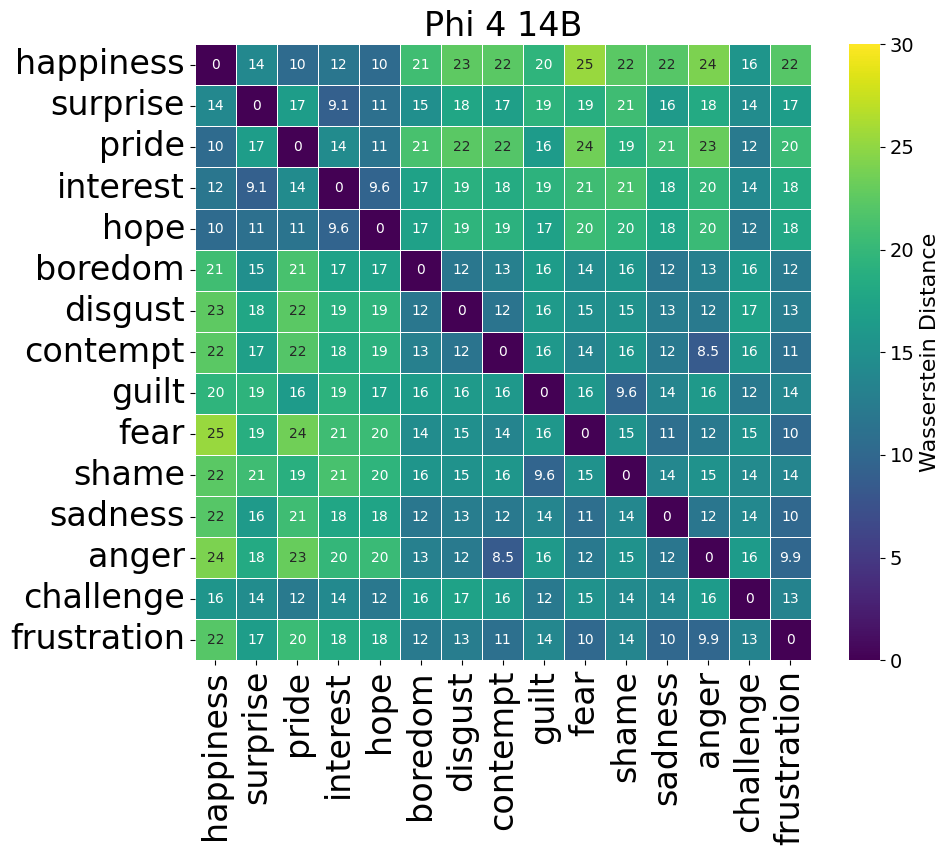

Minimum distance = 8.524265458341736
Maximum distance = 25.366175453600743
Average distace = 16.03930579266873


In [12]:
phi_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/phi_4_with_emotion_vanilla.jsonl")
emotion_distance = get_within_subject_representation(qwq_df, "Phi 4 14B")

plt.figure(figsize=(10, 8))
sns.heatmap(emotion_distance, vmin=0, vmax=30, annot=True, cmap="viridis", square=True, linewidths=0.5, cbar_kws={"label": "Wasserstein Distance"})
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
cbar = plt.gca().collections[0].colorbar
cbar.ax.tick_params(labelsize=14)                 # Tick labels on colorbar
cbar.set_label("Wasserstein Distance", fontsize=16)  # Label font size
plt.title("Phi 4 14B", fontsize=24)
plt.savefig("phi_wasserstein_distance.pdf", format="pdf", bbox_inches="tight")
plt.show()

phi_distribution = find_values(emotion_distance)

pleasantness: 274
enjoyment: 274
consider: 274
attention: 274
understand: 274
control-situational: 274
control-self: 274
control-other: 274
certainty: 274
problem: 274
obstacle: 274
legitimacy-cheated: 274
legitimacy-fair: 274
responsibility-self: 274
responsibility-other: 274
exert: 274
effort: 274
emotion_label: 274


/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_44273/2130613728.py:45: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x)
/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_44273/2130613728.py:46: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: int(x) if isinstance(x, str) and x.isdigit() else x)


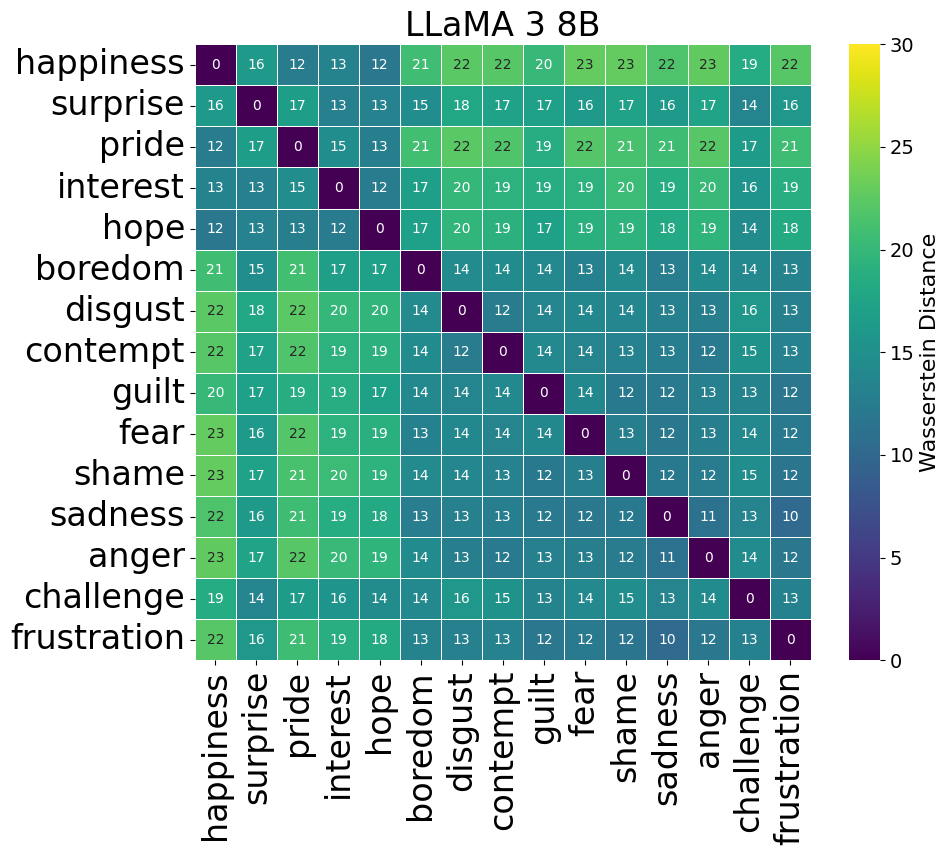

Minimum distance = 10.31079531365064
Maximum distance = 22.844505435036854
Average distace = 16.050037261051674


In [13]:
llama_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/llama_3_8b_with_emotion_vanilla.jsonl")
emotion_distance = get_within_subject_representation(llama_df, "LLaMA 3 8B")

plt.figure(figsize=(10, 8))
sns.heatmap(emotion_distance, vmin=0, vmax=30, annot=True, cmap="viridis", square=True, linewidths=0.5, cbar_kws={"label": "Wasserstein Distance"})
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
cbar = plt.gca().collections[0].colorbar
cbar.ax.tick_params(labelsize=14)                 # Tick labels on colorbar
cbar.set_label("Wasserstein Distance", fontsize=16)  # Label font size
plt.title("LLaMA 3 8B", fontsize=24)
plt.savefig("llama_wasserstein_distance.pdf", format="pdf", bbox_inches="tight")
plt.show()

llama_distribution = find_values(emotion_distance)

<Axes: >

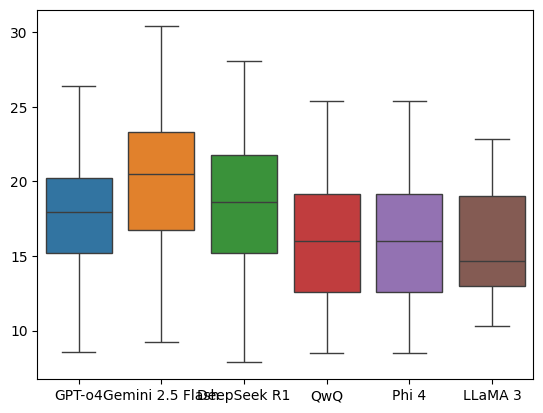

In [102]:
all_dist_distribution = {
    "GPT-o4": gpt_distribution,
    "Gemini 2.5 Flash": gemini_distribution,
    "DeepSeek R1": ds_distribution,
    "QwQ": qwq_distribution,
    "Phi 4": phi_distribution,
    "LLaMA 3": llama_distribution
}


In [116]:
# Example: your 6 model dataframes
# df_gpt, df_gemini, df_ds, df_qwq, df_phi, df_llama

model_dfs = {
    "GPT-o4": gpt_df.apply(lambda x: int(x) if isinstance(x, str) and not x.isdigit() else x),
    "Gemini": gemini_df.apply(lambda x: int(x) if isinstance(x, str) and not x.isdigit() else x),
    "DeepSeek R1": deepseek_r1_df.apply(lambda x: int(x) if isinstance(x, str) and not x.isdigit() else x),
    "QwQ": qwq_df.apply(lambda x: int(x) if isinstance(x, str) and not x.isdigit() else x),
    "Phi": phi_df.apply(lambda x: int(x) if isinstance(x, str) and not x.isdigit() else x),
    "LLaMA": llama_df.apply(lambda x: int(x) if isinstance(x, str) and not x.isdigit() else x),
}

all_cols = list(next(iter(model_dfs.values())).columns)
appraisal_dims = [c for c in all_cols if c.lower() != "emotion_label"]  # adjust if label col named differently

model_order = list(model_dfs.keys())
dim_order = appraisal_dims


In [128]:
rows = []
for model_name, df in model_dfs.items():
    for dim in appraisal_dims:
        for val in df[dim].dropna():
            if dim == "pleasantness" or dim == "attention": 
                if int(val) > 5 or int(val) < -5: 
                    continue
            else: 
                if int(val) < 0 or int(val) > 11: 
                    continue 
            rows.append({
                "model": model_name,
                "dimension": dim,
                "value": float(val),
            })

long_df = pd.DataFrame(rows)

# Ensure ordered categories
long_df["model"] = pd.Categorical(long_df["model"], categories=model_order, ordered=True)
long_df["dimension"] = pd.Categorical(long_df["dimension"], categories=dim_order, ordered=True)

# Z-score normalize per dimension
long_df["value_norm"] = long_df.groupby("dimension")["value"] \
                               .transform(lambda x: (x - x.mean()) / x.std(ddof=1))


/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_91342/3972827134.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  long_df["value_norm"] = long_df.groupby("dimension")["value"] \


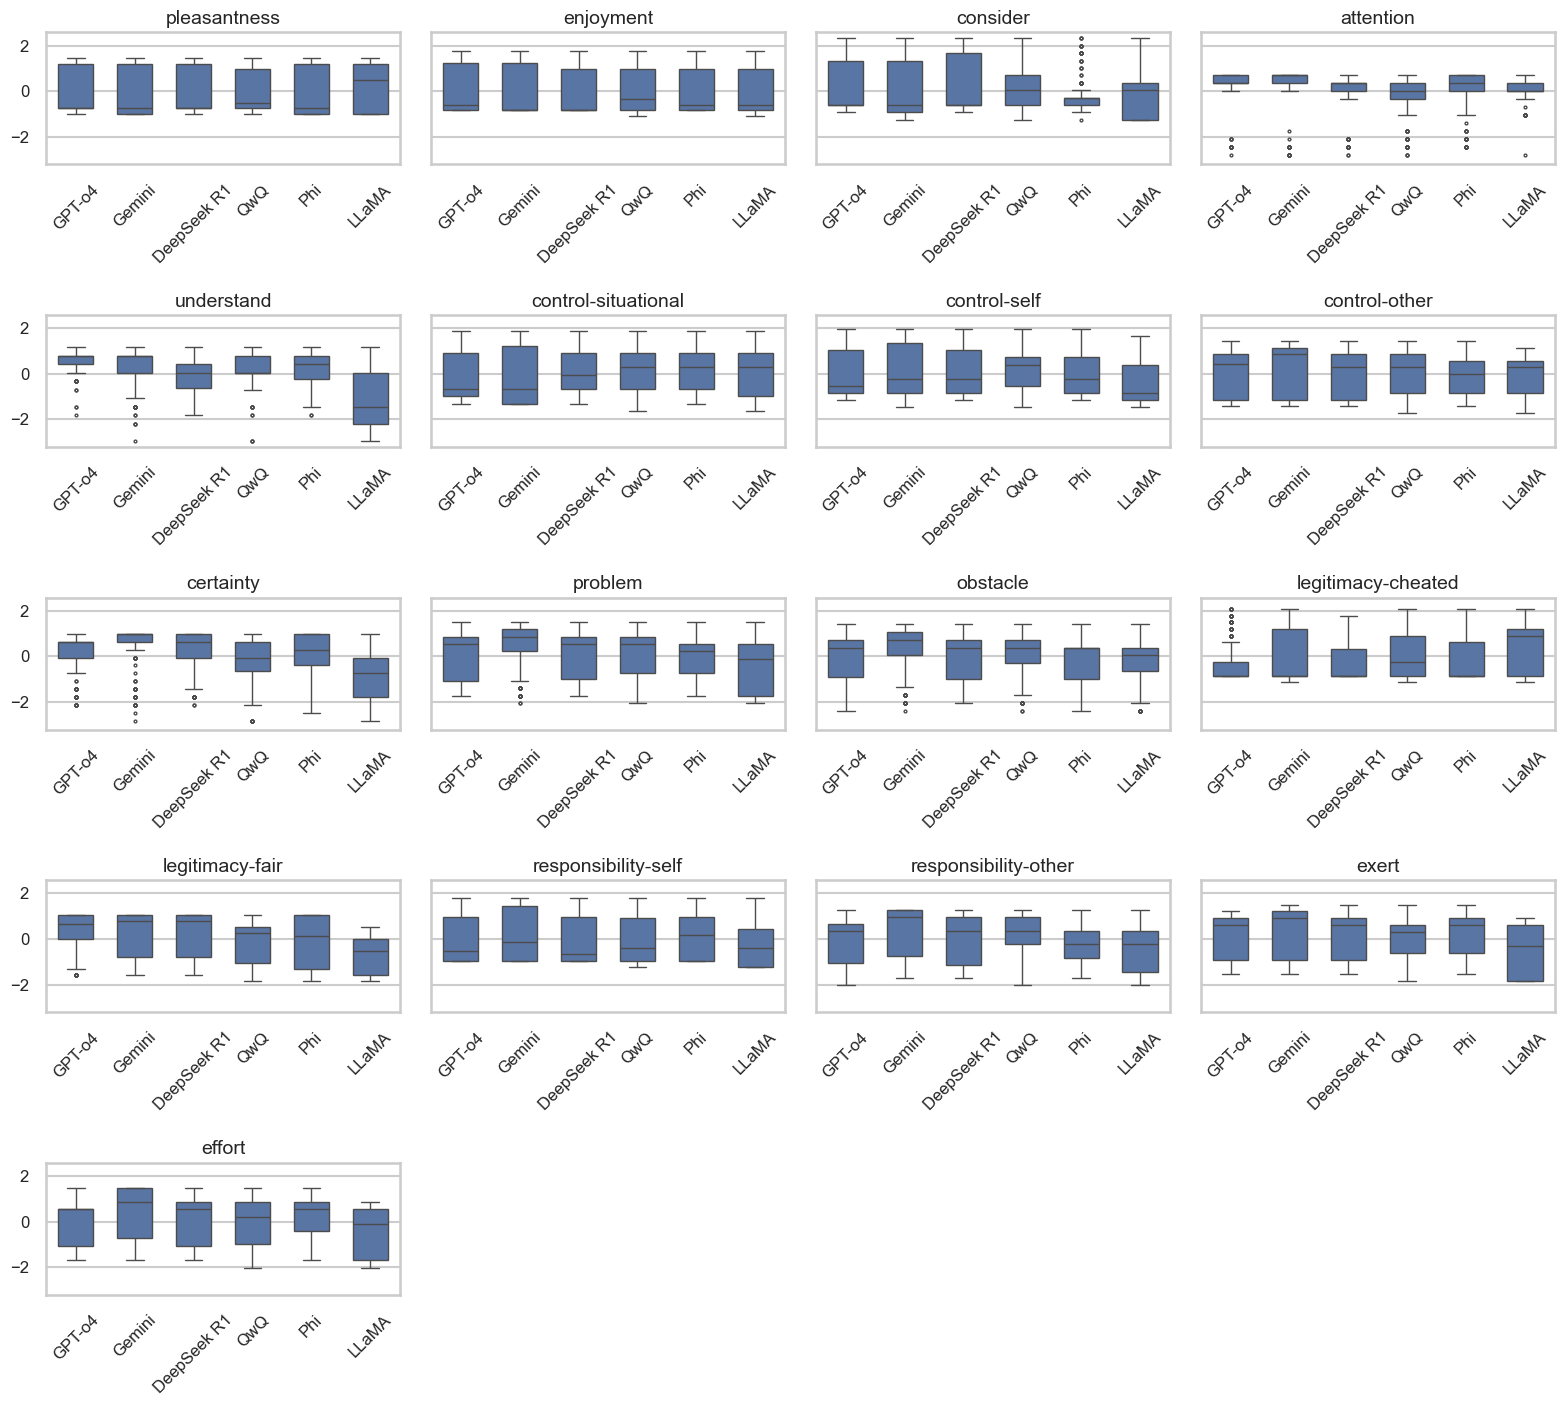

In [130]:
sns.set(style="whitegrid", context="talk")

n_dims = len(dim_order)
n_cols = 4
n_rows = int(np.ceil(n_dims / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3 * n_rows),
    sharey=True,  # same y-scale across panels (good if all on 1–7 etc.)
)

axes = axes.flatten()

for i, dim in enumerate(dim_order):
    ax = axes[i]
    sub = long_df[long_df["dimension"] == dim]

    sns.boxplot(
        data=sub,
        x="model",
        y="value_norm",
        ax=ax,
        width=0.6,
        fliersize=2,   # outlier marker size
    )

    ax.set_title(dim, fontsize=14)
    ax.set_xlabel("")  # avoid clutter
    ax.set_ylabel("")  # we'll rely on shared y-axis
    ax.tick_params(axis="x", rotation=45, labelsize=12)
    ax.tick_params(axis="y", labelsize=12)

    # If your appraisals are on a fixed scale (e.g., 1–7), it’s nice to fix this:
    # ax.set_ylim(-5, 7)

# Hide any unused axes if grid > number of dimensions
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# fig.suptitle("Distribution of Appraisal Dimensions Across Models", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("./results_new/cross_model_mean_variance.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [131]:
def get_discrete_wasserstein(X_1, X_2):
    supp1 = X_1.T
    supp2 = X_2.T

    w1 = np.ones(supp1.shape[1]) / supp1.shape[1]
    w2 = np.ones(supp2.shape[1]) / supp2.shape[1]

    dist_sq, _ = DiscreteWasserstein(supp1, supp2, w1, w2)
            
    return np.sqrt(dist_sq)

In [162]:
all_cols = list(next(iter(model_dfs.values())).columns)
appraisal_dims = [c for c in all_cols if c.lower() != "emotion_label"]

model_names = list(model_dfs.keys())
n_models = len(model_names)

def wasserstein_matrix_for_emotion(emotion_label):
    """
    Returns an n_models x n_models DataFrame of Wasserstein distances
    between models' appraisal distributions for a given emotion.
    """
    dist_mat = np.zeros((n_models, n_models))
    
    for i in range(n_models):
        df_i = model_dfs[model_names[i]]
        Xi = df_i[df_i["emotion_label"] == emotion_label][appraisal_dims].to_numpy().astype(np.float64)

        
        for j in range(i, n_models):
            if i == j:
                dist = 0.0
            else:
                df_j = model_dfs[model_names[j]]
                Xj = df_j[df_j["emotion_label"] == emotion_label][appraisal_dims].to_numpy().astype(np.float64)
                
                # if either model has no samples for this emotion, set NaN
                if len(Xi) == 0 or len(Xj) == 0:
                    dist = np.nan
                else:
                    dist = get_discrete_wasserstein(Xi, Xj)
            
            dist_mat[i, j] = dist
            dist_mat[j, i] = dist  # symmetric
    
    return pd.DataFrame(dist_mat, index=model_names, columns=model_names)

In [163]:
def plot_wasserstein_heatmap(emotion_label, cmap="rocket_r"):
    dist_df = wasserstein_matrix_for_emotion(emotion_label)
    
    sns.set(style="whitegrid", context="talk")
    plt.figure(figsize=(12, 8))
    ax = sns.heatmap(
        dist_df,
        annot=True,
        fmt=".3f",
        cmap=cmap,
        linewidths=0.5,
        linecolor="white",
        square=True,
        cbar_kws={"label": "Wasserstein distance"}
    )
    
    plt.title(f"{emotion_label}")
    # plt.xlabel("Model")
    # plt.ylabel("Model")
    plt.tight_layout()
    plt.show()


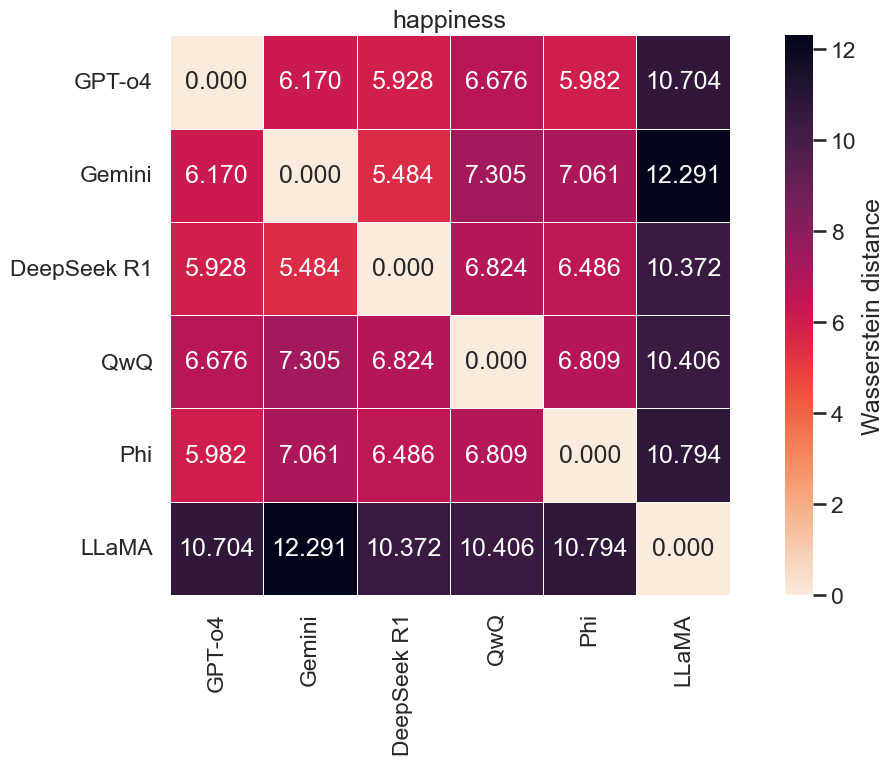

In [164]:
plot_wasserstein_heatmap("happiness")

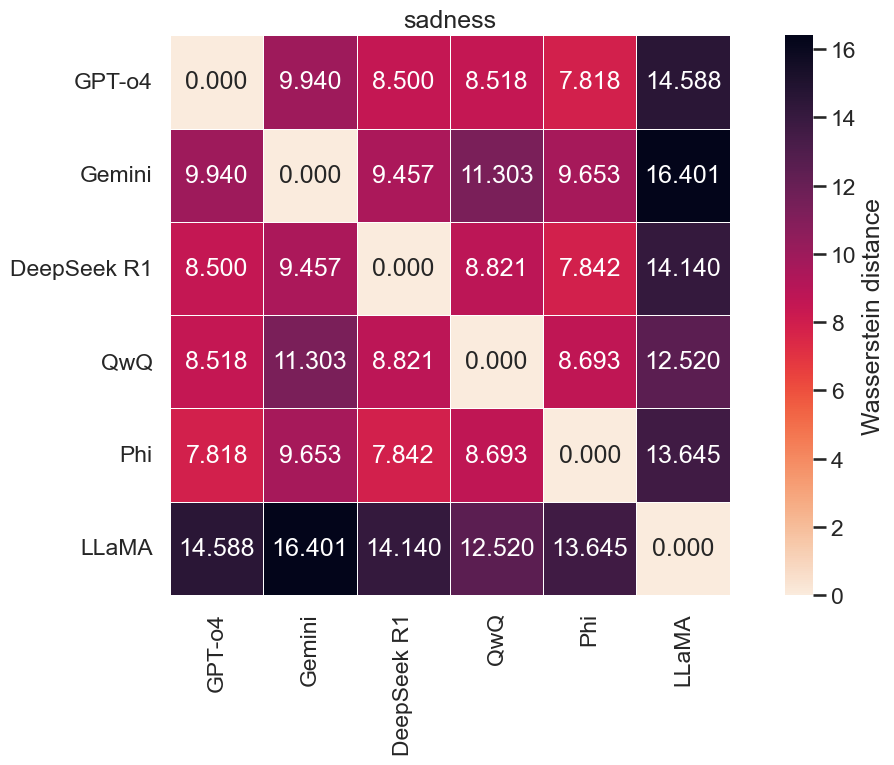

In [165]:
plot_wasserstein_heatmap("sadness")

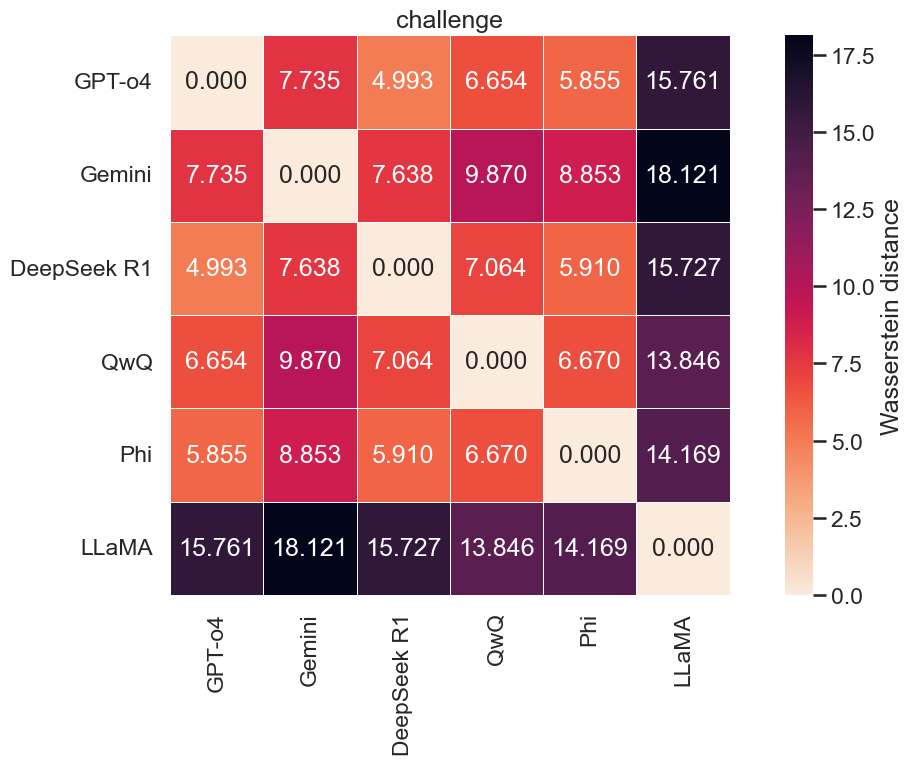

In [166]:
plot_wasserstein_heatmap("challenge")

In [167]:
import numpy as np
from sklearn.metrics.pairwise import rbf_kernel

def mmd_rbf(X, Y, gamma=1.0):
    """Compute unbiased MMD^2 between two sets X and Y."""
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)

    n = len(X)
    m = len(Y)

    # unbiased estimator
    term_xx = (np.sum(Kxx) - np.sum(np.diag(Kxx))) / (n*(n-1))
    term_yy = (np.sum(Kyy) - np.sum(np.diag(Kyy))) / (m*(m-1))
    term_xy = np.sum(Kxy) / (n*m)

    return term_xx + term_yy - 2*term_xy

def mmd_test(X, Y, num_perm=2000, gamma=1.0):
    """Return (observed MMD, p-value) using permutation test."""
    observed = mmd_rbf(X, Y, gamma=gamma)
    Z = np.vstack([X, Y])
    n = len(X)

    perm_stats = []
    for _ in range(num_perm):
        perm = np.random.permutation(len(Z))
        Xp = Z[perm[:n]]
        Yp = Z[perm[n:]]
        perm_stats.append(mmd_rbf(Xp, Yp, gamma=gamma))

    p_value = np.mean(np.array(perm_stats) >= observed)
    return observed, p_value


In [169]:
import pandas as pd
from itertools import combinations

model_names = list(model_dfs.keys())

def compute_mmd_matrix_for_emotion(emotion_label, gamma=1.0, num_perm=2000, return_pvalues=False):
    k = len(model_names)
    MMD = np.zeros((k, k))
    PVAL = np.ones((k, k))

    for i, model_i in enumerate(model_names):
        Xi = model_dfs[model_i]
        Xi = Xi[Xi["emotion_label"] == emotion_label][appraisal_dims].to_numpy().astype(np.float64)

        for j, model_j in enumerate(model_names):
            if j < i:
                # symmetric matrix
                MMD[i, j] = MMD[j, i]
                PVAL[i, j] = PVAL[j, i]
                continue

            Xj = model_dfs[model_j]
            Xj = Xj[Xj["emotion_label"] == emotion_label][appraisal_dims].to_numpy().astype(np.float64)

            if len(Xi) == 0 or len(Xj) == 0:
                MMD[i, j] = np.nan
                PVAL[i, j] = np.nan
                continue

            # MMD statistic + p-value
            stat, p = mmd_test(Xi, Xj, num_perm=num_perm, gamma=gamma)
            MMD[i, j] = stat
            PVAL[i, j] = p

            # symmetric
            MMD[j, i] = stat
            PVAL[j, i] = p

    if return_pvalues:
        return (pd.DataFrame(MMD, index=model_names, columns=model_names),
                pd.DataFrame(PVAL, index=model_names, columns=model_names))
    else:
        return pd.DataFrame(MMD, index=model_names, columns=model_names)


In [183]:
def plot_pvalue_heatmap(pval_mat, emotion_label):
    plt.figure(figsize=(7,5))
    sns.heatmap(
        pval_mat,
        annot=True,
        fmt=".3f",
        annot_kws={"size": 8},
        cmap="YlGnBu_r",   # p-value palettes
        vmin=0,
        vmax=1,
        linewidths=0,
        linecolor="white"
    )
    # plt.title(f"MMD Test p-values Between Models\nEmotion: {emotion_label}")
    plt.title(f"{emotion_label.capitalize()}")
    # plt.xlabel("Model")
    # plt.ylabel("Model")
    plt.tight_layout()
    plt.show()

In [200]:
mmd_matrices = {
    "happiness": compute_mmd_matrix_for_emotion("happiness", return_pvalues=True)[1], 
    "surprise": compute_mmd_matrix_for_emotion("surprise", return_pvalues=True)[1], 
    "hope": compute_mmd_matrix_for_emotion("hope", return_pvalues=True)[1], 
    "interest": compute_mmd_matrix_for_emotion("interest", return_pvalues=True)[1], 
    "pride": compute_mmd_matrix_for_emotion("pride", return_pvalues=True)[1], 
    "boredom": compute_mmd_matrix_for_emotion("boredom", return_pvalues=True)[1], 
    "challenge": compute_mmd_matrix_for_emotion("challenge", return_pvalues=True)[1], 
    "guilt": compute_mmd_matrix_for_emotion("guilt", return_pvalues=True)[1], 
    "shame": compute_mmd_matrix_for_emotion("shame", return_pvalues=True)[1], 
    "frustration": compute_mmd_matrix_for_emotion("frustration", return_pvalues=True)[1], 
    "fear": compute_mmd_matrix_for_emotion("fear", return_pvalues=True)[1], 
    "anger": compute_mmd_matrix_for_emotion("anger", return_pvalues=True)[1], 
    "sadness": compute_mmd_matrix_for_emotion("sadness", return_pvalues=True)[1], 
    "disgust": compute_mmd_matrix_for_emotion("disgust", return_pvalues=True)[1], 
    "contempt": compute_mmd_matrix_for_emotion("contempt", return_pvalues=True)[1], 
}

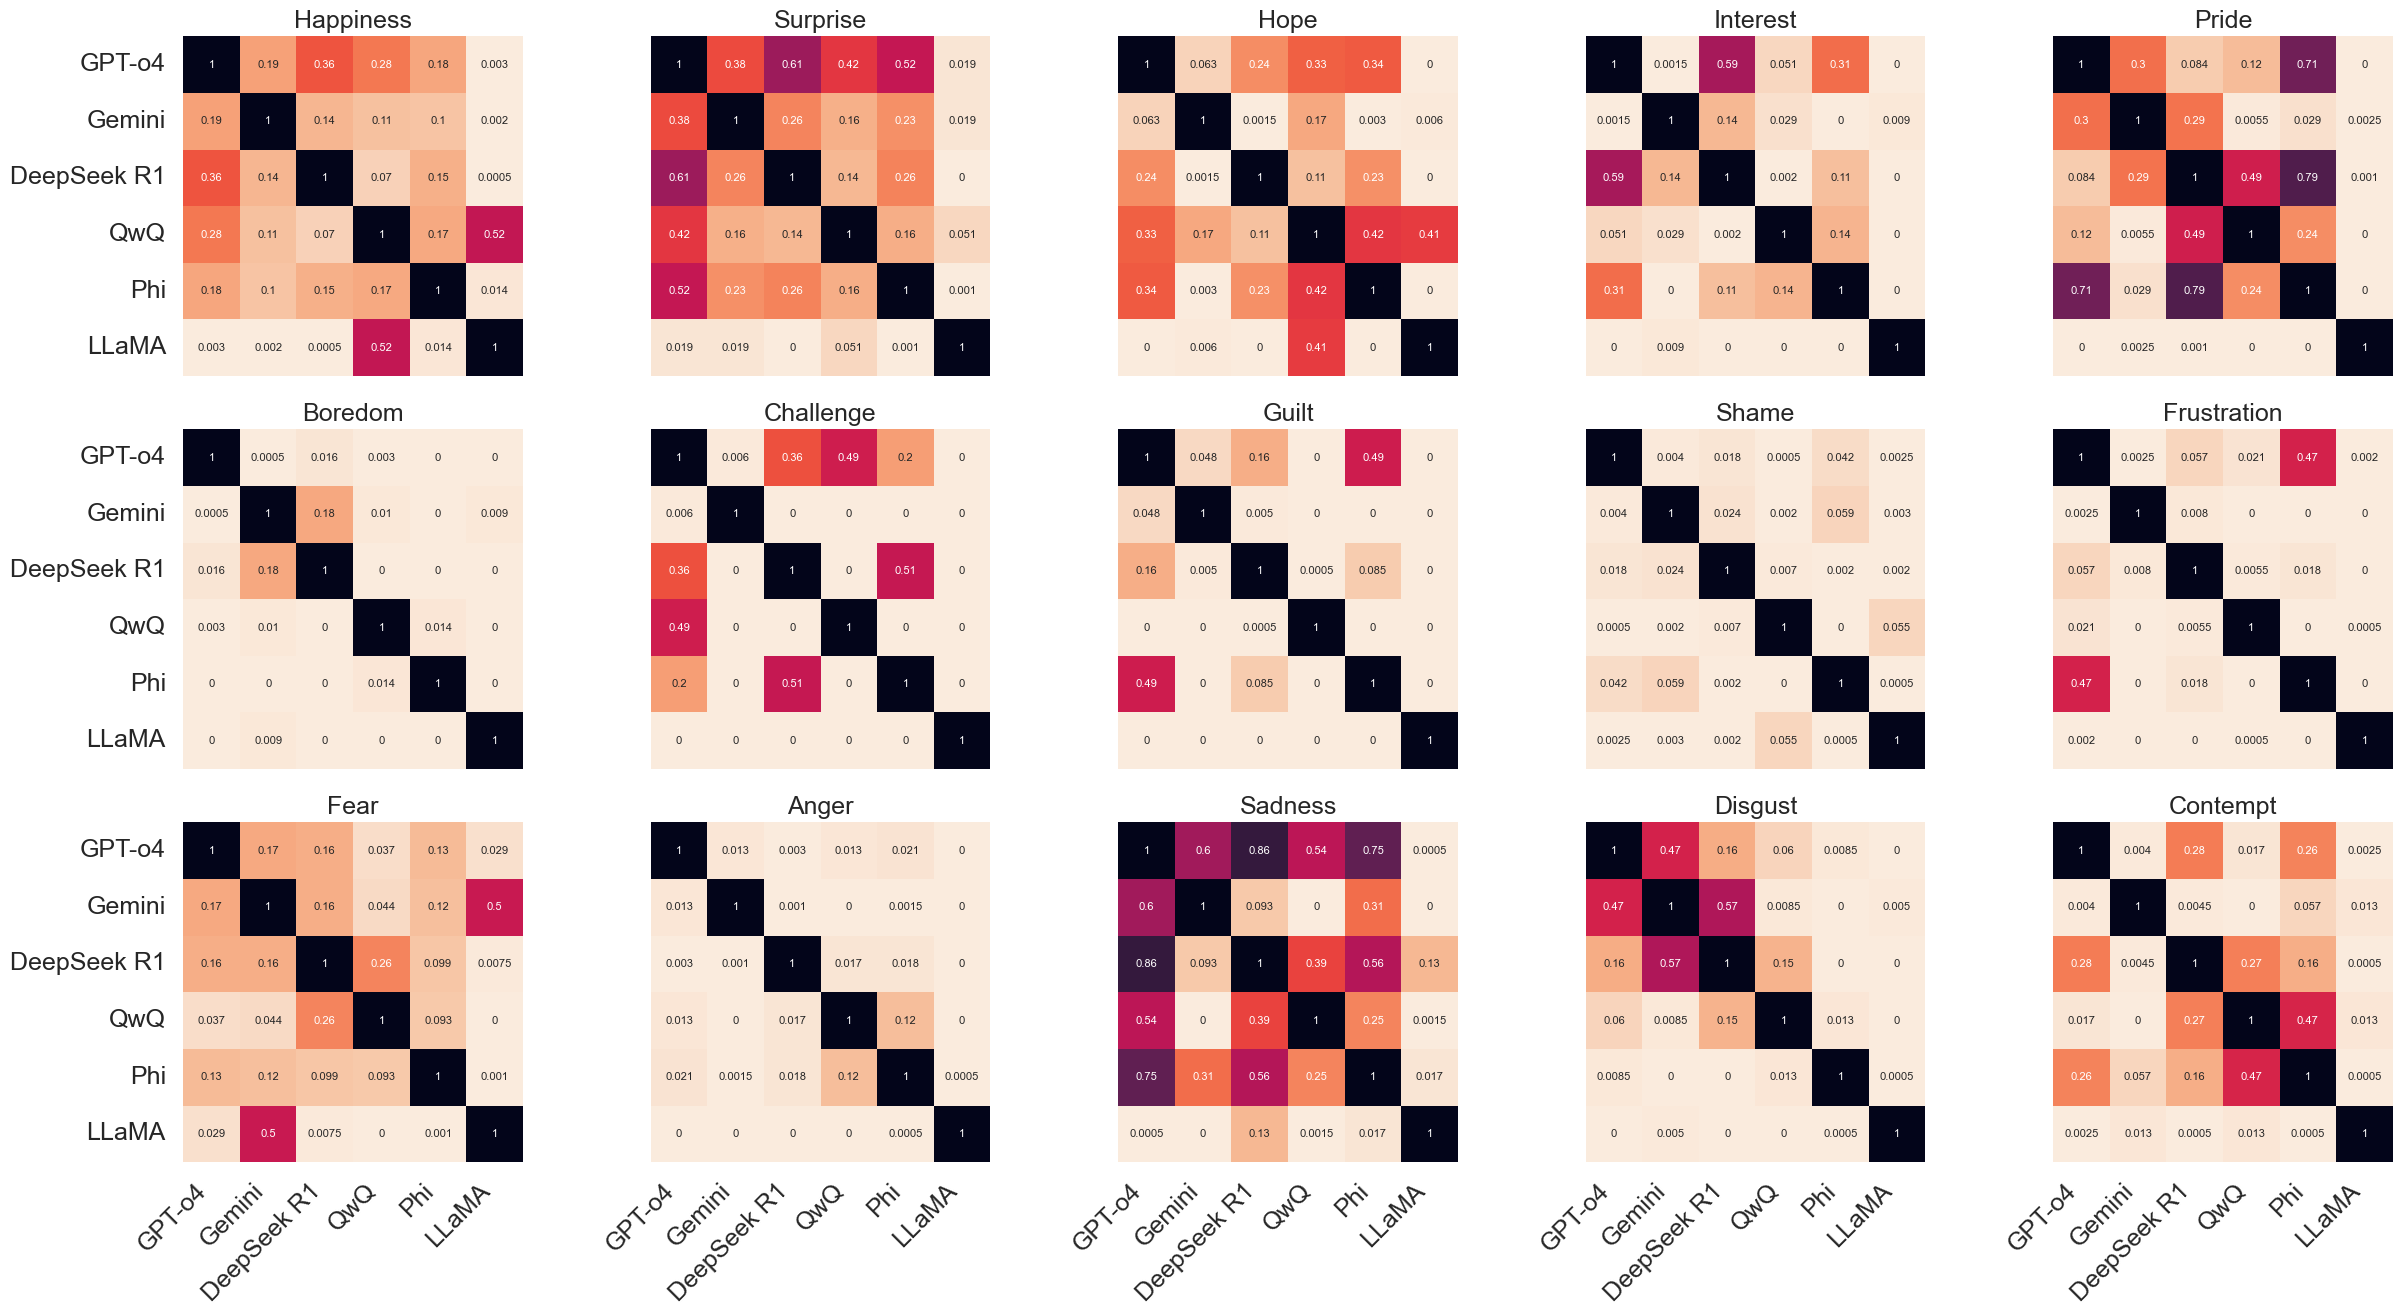

In [228]:
emotions = list(mmd_matrices.keys())
n = len(emotions)

model_names = mmd_matrices[emotions[0]].columns.tolist()

# Grid shape
n_cols = 5
n_rows = int(np.ceil(n / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4.5 * n_rows),
    sharex=False, sharey=False
)

axes = axes.flatten()

# Global vmin/vmax for consistency
vmin = min(mat.min().min() for mat in mmd_matrices.values())
vmax = max(mat.max().max() for mat in mmd_matrices.values())

for i, emo in enumerate(emotions):
    ax = axes[i]
    mat = mmd_matrices[emo]

    sns.heatmap(
        mat,
        ax=ax,
        cmap="rocket_r",
        annot=True,
        annot_kws={"size":8},
        vmin=vmin, vmax=vmax,
        cbar=False,
        square=True,
        linewidths=0,
        linecolor="white"
    )

    ax.set_title(emo.capitalize(), fontsize=18)

    # ----- Add model labels only on OUTER edges -----

    row = i // n_cols
    col = i % n_cols

    # bottom row -> x-axis labels
    if row == n_rows - 1:
        ax.set_xticks(np.arange(len(model_names)) + 0.5)
        ax.set_xticklabels(model_names, rotation=45, ha="right", fontsize=18)
    else:
        ax.set_xticks([])
        ax.set_xticklabels([])

    # leftmost col -> y-axis labels
    if col == 0:
        ax.set_yticks(np.arange(len(model_names)) + 0.5)
        ax.set_yticklabels(model_names, fontsize=18)
    else:
        ax.set_yticks([])
        ax.set_yticklabels([])

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# ----- Shared Colorbar -----
norm = plt.cm.ScalarMappable(cmap="rocket_r")
norm.set_clim(vmin, vmax)

# attach to LAST axis only (prevents overlap)
# cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
# cbar = fig.colorbar(norm, ax=axes, shrink=1, location='bottom')
# cbar.set_label("P-Value of Comparison", fontsize=12)

plt.tight_layout()
plt.savefig("./results_new/distributional_similarity_across_models.pdf", format="pdf", bbox_inches="tight")
plt.show()


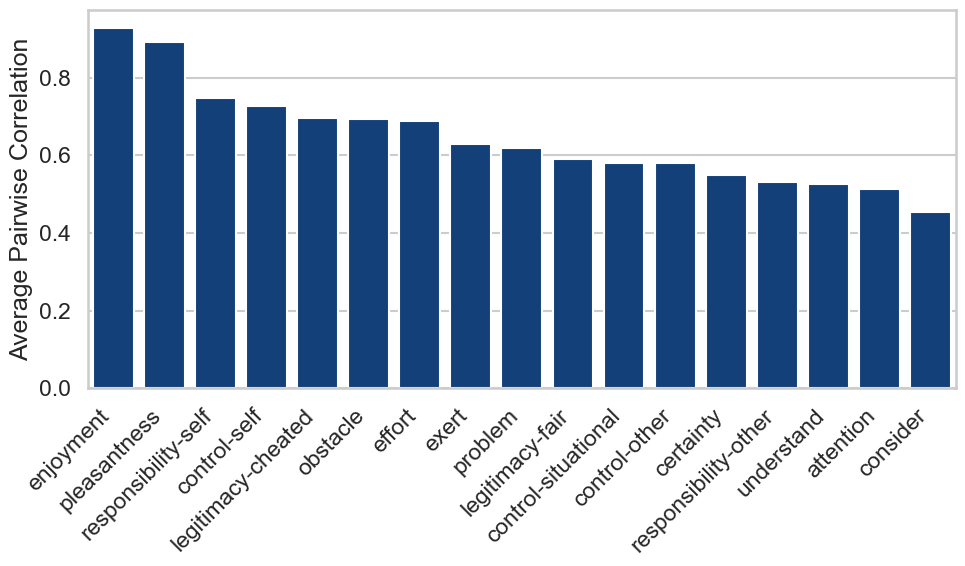

In [242]:
all_cols = list(next(iter(model_dfs.values())).columns)
appraisal_dims = [c for c in all_cols if c.lower() != "emotion_label"]

import numpy as np
import pandas as pd
from itertools import combinations

model_names = list(model_dfs.keys())

avg_corr_per_dim = {}

for dim in appraisal_dims:
    corrs = []
    # Loop over all 6C2 model pairs
    for m1, m2 in combinations(model_names, 2):
        x = model_dfs[m1][dim].astype(float)
        y = model_dfs[m2][dim].astype(float)

        # Ensure aligned indexing and drop NaNs
        df = pd.concat([x, y], axis=1).dropna()
        if len(df) > 1:
            corr = df.corr().iloc[0,1]
            corrs.append(corr)

    # mean correlation for this dimension
    avg_corr_per_dim[dim] = np.mean(corrs) if len(corrs) > 0 else np.nan

avg_corr_per_dim
corr_df = pd.DataFrame.from_dict(avg_corr_per_dim, orient="index", columns=["avg_corr"])
corr_df = corr_df.sort_values("avg_corr", ascending=False)


plt.figure(figsize=(10,6))
sns.barplot(data=corr_df, x=corr_df.index, y="avg_corr", color="#023e8a")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Pairwise Correlation")
plt.xlabel("")
# plt.title("Cross-Model Agreement per Appraisal Dimension")
plt.tight_layout()
plt.savefig("./results_new/average_pairwise_correlation.pdf", format="pdf", )
plt.show()